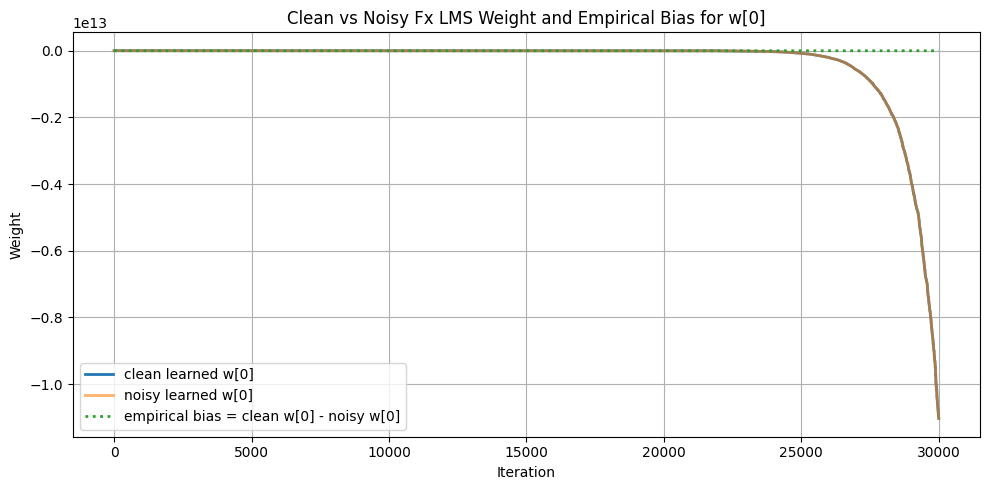

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helper functions
# -------------------------------------------------

def past_vector(signal, n, L):
    """
    Returns [signal[n], signal[n-1], ..., signal[n-L+1]]
    with zero-padding for negative indices.
    """
    vec = np.zeros(L)
    for k in range(L):
        if n - k >= 0:
            vec[k] = signal[n - k]

    return vec


def moving_average(x, window):
    """
    Simple moving average for smoother plots.
    """
    window = min(window, len(x))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


def run_Fxlms_inverse_control(r, h_hat, h, h_m, M, mu, w0, noise=0, clean=False):

    N = len(r)
    Lp = len(h)
    Lhat = len(h_hat)
    Lm = len(h_m)

    # Adaptive weights
    w = w0.copy()

    # Scalar signal histories
    u = np.zeros(N)
    c = np.zeros(N)
    y = np.zeros(N)
    e = np.zeros(N)
    d = np.zeros(N)
    y_hat = np.zeros(N)

    # Weight history
    w_hist = np.zeros((N, M))

    for n in range(N):

        # Copy adaptive controller: u_j = w_j^T r_j
        r_vec = past_vector(r, n, M)
        u[n] = np.dot(w, r_vec)

        # Unknown plant: c_j = h^T u_j
        u_vec = past_vector(u, n, Lp)
        c[n] = np.dot(h, u_vec)
        if clean:
            y[n] = c[n] # No noise case
        else:
            y[n] = c[n] + noise[n] # Add noise to plant output
        
        # Estimated output of unknown plant
        r_hat_vec = past_vector(r, n, Lhat)
        y_hat[n] = np.dot(h_hat, r_hat_vec)
        
        y_hat_vec = past_vector(y_hat, n, M)



        # Reference model
        # Reference model output
        r_model_vec = past_vector(r, n, Lm)
        d[n] = np.dot(h_m, r_model_vec)
        e[n] = d[n] - y[n]

        w = w - mu * e[n] * y_hat_vec

        # Store updated weights
        w_hist[n, :] = w


    return {
        "u": u,
        "c": c,
        "y": y,
        "d": d,
        "e": e,
        "y_hat": y_hat,
        "w_hist": w_hist,
    }



# Simulation parameters
fs = 1000
T = 30
N = 30000
M = 3
mu = 0.001

h = np.array([0, 1, 0])
h_hat = np.array([0, 1, 0])
h_m = np.array([0, 1, 0])
w0 = np.array([0, 0, 0.1])

input_seed = 1
noise_seed = 2

rng_input = np.random.default_rng(input_seed)
rng_noise = np.random.default_rng(noise_seed)

noise_std = 0.2

r = rng_input.standard_normal(N)
noise = noise_std * rng_noise.standard_normal(N)
# Input signal: same every time
r = rng_input.standard_normal(N)

# -------------------------------------------------
# Run clean and noisy simulations
# -------------------------------------------------

clean = run_Fxlms_inverse_control(
    r=r,
    h_hat=h_hat,
    h=h,
    h_m=h_m,
    M=M,
    mu=mu,
    w0=w0,
    clean=True
)

noisy = run_Fxlms_inverse_control(
    r=r,
    h_hat=h_hat,
    h=h,
    h_m=h_m,
    M=M,
    mu=mu,
    w0=w0,
    noise=noise,
    clean=False
)

# Bias/difference between clean and noisy weight trajectories
delta_w = clean["w_hist"] - noisy["w_hist"]

# -------------------------------------------------
# Plot settings
# -------------------------------------------------

plot_start = 0
iters = np.arange(plot_start, N)


# -------------------------------------------------
# Plot 1: one weight, clean vs noisy vs bias
# -------------------------------------------------

k = 0

plt.figure(figsize=(10, 5))

plt.plot(
    iters,
    clean["w_hist"][plot_start:, k],
    label=f"clean learned w[{k}]",
    linewidth=2,
)

plt.plot(
    iters,
    noisy["w_hist"][plot_start:, k],
    label=f"noisy learned w[{k}]",
    linewidth=2,
    alpha=0.6,

)

plt.plot(
    iters,
    delta_w[plot_start:, k],
    ":",
    label=f"empirical bias = clean w[{k}] - noisy w[{k}]",
    linewidth=2,
)

plt.title(f"Clean vs Noisy Fx LMS Weight and Empirical Bias for w[{k}]")
plt.xlabel("Iteration")
plt.ylabel("Weight")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



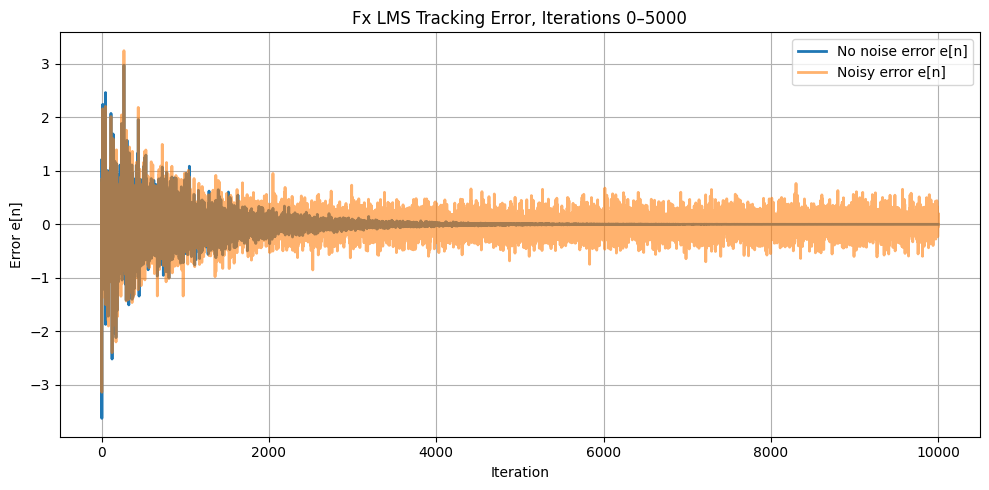

In [29]:
plot_start = 0
plot_end = 10000

iters = np.arange(plot_start, plot_end)

plt.figure(figsize=(10, 5))

plt.plot(
    iters,
    clean["e"][plot_start:plot_end],
    label="No noise error e[n]",
    linewidth=2
)

plt.plot(
    iters,
    noisy["e"][plot_start:plot_end],
    label="Noisy error e[n]",
    linewidth=2,
    alpha=0.6
)

plt.title("Fx LMS Tracking Error, Iterations 0–5000")
plt.xlabel("Iteration")
plt.ylabel("Error e[n]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# -------------------------------------------------
# Monte Carlo convergence test using ONLY your function
# -------------------------------------------------

noise_stds = np.array([0.20, 0.25, 0.30, 0.35, 0.40])
trials_per_noise = 10

rows = []
trial_rows = []
tail_start = int(0.8 * N)

for i, ns in enumerate(noise_stds):

    rng_noise = np.random.default_rng(50000 + i)

    noise_bank = ns * rng_noise.standard_normal((N, trials_per_noise))

    w0_values = []
    successes = []

    for t in range(trials_per_noise):

        noise_trial = noise_bank[:, t]

        sim = run_Fxlms_inverse_control(
            r=r,
            h=h,
            h_hat=h_hat,
            h_m=h_m,
            M=M,
            mu=mu,
            w0=w0,
            noise=noise_trial,
            clean=False
        )

        # Only use w[0]
        w0_tail_mean = np.mean(sim["w_hist"][tail_start:, 0])

        success = w0_tail_mean > 0.5

        w0_values.append(w0_tail_mean)
        successes.append(success)

        trial_rows.append({
            "noise_std": ns,
            "trial": t,
            "w0_tail_mean": w0_tail_mean,
            "success": bool(success),
        })

    w0_values = np.array(w0_values)
    successes = np.array(successes)
    success_rate = np.mean(successes)

    print(
        f"noise_std = {ns:.2f}, "
        f"success_rate = {success_rate:.2f}, "
        f"mean final w[0] = {np.mean(w0_values):.4f}, "
        f"std final w[0] = {np.std(w0_values):.4f}"
    )

noise_std = 0.20, success_rate = 1.00, mean final w[0] = 0.9991, std final w[0] = 0.0008
noise_std = 0.25, success_rate = 1.00, mean final w[0] = 0.9990, std final w[0] = 0.0040
noise_std = 0.30, success_rate = 1.00, mean final w[0] = 1.0007, std final w[0] = 0.0033
noise_std = 0.35, success_rate = 1.00, mean final w[0] = 1.0016, std final w[0] = 0.0042
noise_std = 0.40, success_rate = 1.00, mean final w[0] = 1.0005, std final w[0] = 0.0044


In [ ]:
import warnings
import numpy as np
mu_values = np.array([0.0001, 0.001, 0.01, 0.1])

noise_std = 0.20
num_runs = 5

tail_start = int(0.8 * N)

rng_noise = np.random.default_rng(60000)
noise_bank = noise_std * rng_noise.standard_normal((N, num_runs))

for mu_test in mu_values:

    successes = 0
    w0_results = []

    for run in range(num_runs):

        noise_trial = noise_bank[:, run]

        # Hide overflow warnings, but still detect failure below
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)

            sim = run_Fxlms_inverse_control(
                r=r,
                h_hat=h_hat,
                h=h,
                h_m=h_m,
                M=M,
                mu=mu_test,
                w0=w0,
                noise=noise_trial,
                clean=False
            )

        w0_tail_mean = np.mean(sim["w_hist"][tail_start:, 0])
        w0_results.append(w0_tail_mean)

        if np.isfinite(w0_tail_mean) and w0_tail_mean > 0.5:
            successes += 1

    success_percent = 100 * successes / num_runs

    finite_w0 = np.array(w0_results)[np.isfinite(w0_results)]

    if len(finite_w0) > 0:
        mean_w0 = np.mean(finite_w0)
    else:
        mean_w0 = np.nan

    if success_percent >= 80:
        status = "WORKS"
    else:
        status = "DOES NOT WORK"

    print(
        f"mu = {mu_test:.4f}, "
        f"success = {success_percent:.0f}%, "
        f"mean final w[0] = {mean_w0:.4f}, "
        f"{status}"
    )

NameError: name 'run_lms_inverse_control' is not defined

In [18]:
# -------------------------------------------------
# Controller-length sweep
# -------------------------------------------------

N = 30000
mu = 0.01
noise_std = 0.2

input_seed = 123
noise_seed = 456

rng_input = np.random.default_rng(input_seed)
rng_noise = np.random.default_rng(noise_seed)

r = rng_input.standard_normal(N)
noise = noise_std * rng_noise.standard_normal(N)

# Use your original simple case
h = np.array([0, 1, 0])
h_hat = np.array([0, 1, 0])
h_m = np.array([0, 1, 0])

M_values = np.array([1, 2, 3, 4, 5, 8, 10, 15])

tail_start = int(0.8 * N)

final_mse = []
final_w0 = []

for M_test in M_values:

    w0_test = np.zeros(M_test)
    w0_test[0] = 0.1

    sim = run_Fxlms_inverse_control(
        r=r,
        h_hat=h_hat,
        h=h,
        h_m=h_m,
        M=M_test,
        mu=mu,
        w0=w0_test,
        noise=noise,
        clean=False
    )

    mse_tail = np.mean(sim["e"][tail_start:]**2)
    w0_tail = np.mean(sim["w_hist"][tail_start:, 0])

    final_mse.append(mse_tail)
    final_w0.append(w0_tail)

    print(
        f"M = {M_test:2d}, "
        f"tail MSE = {mse_tail:.6f}, "
        f"mean final w[0] = {w0_tail:.4f}"
    )

final_mse = np.array(final_mse)
final_w0 = np.array(final_w0)

M =  1, tail MSE = 0.038845, mean final w[0] = 0.9981
M =  2, tail MSE = 0.039061, mean final w[0] = 0.9982
M =  3, tail MSE = 0.039220, mean final w[0] = 0.9981
M =  4, tail MSE = 0.039440, mean final w[0] = 0.9980
M =  5, tail MSE = 0.039620, mean final w[0] = 0.9978
M =  8, tail MSE = 0.040232, mean final w[0] = 0.9976
M = 10, tail MSE = 0.040680, mean final w[0] = 0.9982
M = 15, tail MSE = 0.041790, mean final w[0] = 0.9986


In [19]:
# -------------------------------------------------
# Plant-model mismatch experiment
# -------------------------------------------------

N = 30000
M = 3
mu = 0.01
noise_std = 0.2

input_seed = 123
noise_seed = 456

rng_input = np.random.default_rng(input_seed)
rng_noise = np.random.default_rng(noise_seed)

r = rng_input.standard_normal(N)
noise = noise_std * rng_noise.standard_normal(N)

# True plant and reference model
h = np.array([0, 1, 0])
h_m = np.array([0, 1, 0])

# Test gain mismatch in the plant model
model_gains = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0])

tail_start = int(0.8 * N)

mismatch_mse = []
mismatch_w0 = []

for gain in model_gains:

    h_hat_test = np.array([0, gain, 0])

    w0_test = np.array([0.1, 0.0, 0.0])

    sim = run_Fxlms_inverse_control(
        r=r,
        h_hat=h_hat_test,
        h=h,
        h_m=h_m,
        M=M,
        mu=mu,
        w0=w0_test,
        noise=noise,
        clean=False
    )

    mse_tail = np.mean(sim["e"][tail_start:]**2)
    w0_tail = np.mean(sim["w_hist"][tail_start:, 0])

    mismatch_mse.append(mse_tail)
    mismatch_w0.append(w0_tail)

    print(
        f"h_hat gain = {gain:.2f}, "
        f"tail MSE = {mse_tail:.6f}, "
        f"mean final w[0] = {w0_tail:.4f}"
    )

h_hat gain = 0.25, tail MSE = 0.038760, mean final w[0] = 0.9977
h_hat gain = 0.50, tail MSE = 0.038922, mean final w[0] = 0.9979
h_hat gain = 0.75, tail MSE = 0.039073, mean final w[0] = 0.9980
h_hat gain = 1.00, tail MSE = 0.039220, mean final w[0] = 0.9981
h_hat gain = 1.25, tail MSE = 0.039364, mean final w[0] = 0.9981
h_hat gain = 1.50, tail MSE = 0.039509, mean final w[0] = 0.9982
h_hat gain = 2.00, tail MSE = 0.039810, mean final w[0] = 0.9982


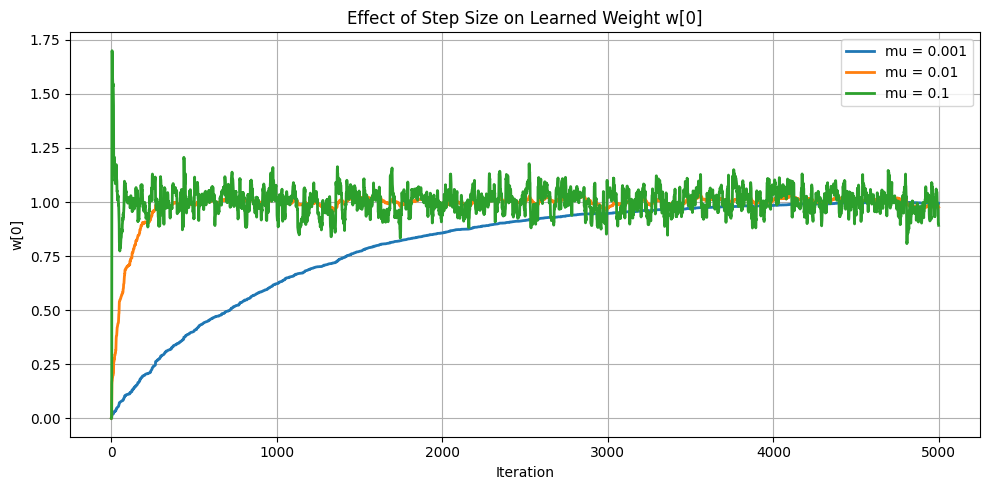

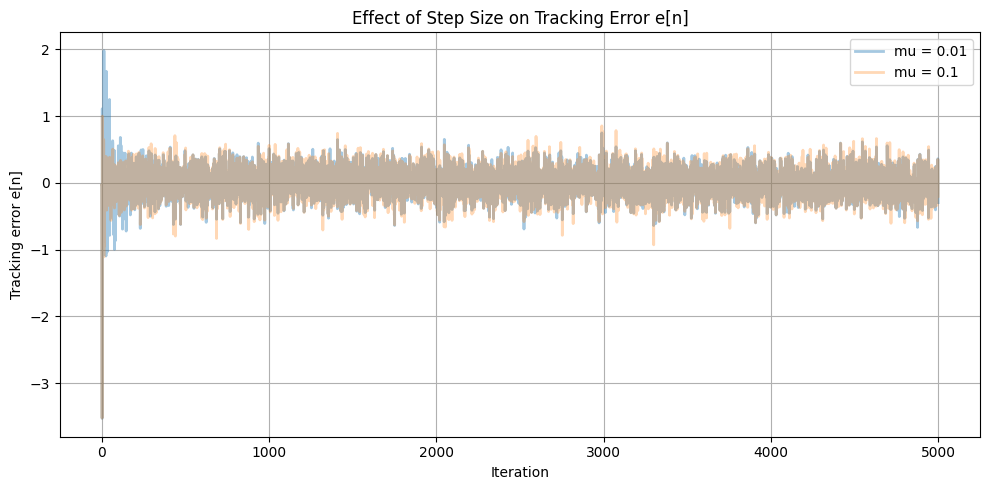

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import warnings


# Test three step sizes
mu_values = [0.001, 0.01, 0.1]
results = {}

for mu_test in mu_values:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        sim = run_Fxlms_inverse_control(
            r=r,
            h_hat=h_hat,
            h=h,
            h_m=h_m,
            M=M,
            mu=mu_test,
            w0=w0,
            noise=noise,
            clean=False
        )

    results[mu_test] = sim

# -------------------------------------------------
# Plot 1: learned weight w[0]
# -------------------------------------------------

plot_end = 5000
iters = np.arange(plot_end)

plt.figure(figsize=(10, 5))

for mu_test in mu_values:
    w_plot = results[mu_test]["w_hist"][:plot_end, 0]
    plt.plot(iters, w_plot, label=f"mu = {mu_test}", linewidth=2)

plt.title("Effect of Step Size on Learned Weight w[0]")
plt.xlabel("Iteration")
plt.ylabel("w[0]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot 2: tracking error e[n]
# -------------------------------------------------

plt.figure(figsize=(10, 5))

for mu_test in mu_values:
    e_plot = results[mu_test]["e"][:plot_end]
    if mu_test == 0.10:
        plt.plot(iters, e_plot, label=f"mu = {mu_test}", linewidth=2,alpha=0.3)
    if mu_test == 0.010:
        plt.plot(iters, e_plot, label=f"mu = {mu_test}", linewidth=2,alpha=0.4)



plt.title("Effect of Step Size on Tracking Error e[n]")
plt.xlabel("Iteration")
plt.ylabel("Tracking error e[n]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()